In [3]:
# toxic-comments.csv
# https://mitu.co.in/datasets

#### Imports necessary Libraries

In [53]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import re

In [2]:
df = pd.read_csv('toxic-comments.csv')
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
df.shape

(159571, 8)

In [5]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [6]:
df.dtypes

id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object

In [10]:
comments = df.sum(numeric_only = True)
comments

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [11]:
comments.sum()

35098

<BarContainer object of 6 artists>

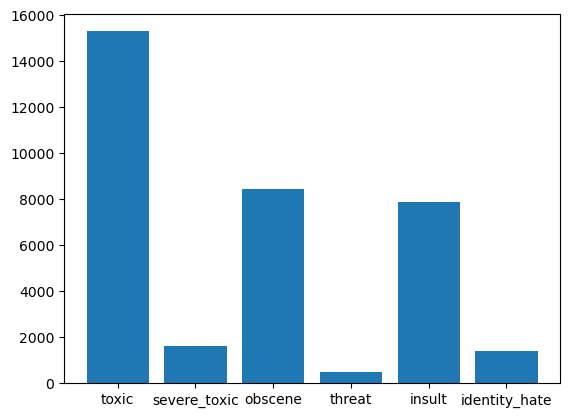

In [12]:
plt.bar(comments.index, comments)

([<matplotlib.patches.Wedge at 0x1ea7ad009b0>,
 [Text(0.03140289415264145, 1.1495711627554155, 'toxic'),
  Text(-1.1457116737712996, 0.09922076689971465, 'severe_toxic'),
  Text(-0.7907184113700997, -0.8350235888406661, 'obscene'),
  Text(0.04701691766575235, -1.149038471702846, 'threat'),
  Text(0.8158895889682662, -0.8104469005512906, 'insult'),
  Text(1.1486324869875228, 0.056066120222985724, 'identity_hate')],
 [Text(0.017749461912362555, 0.6497576137313218, '43.58%'),
  Text(-0.6475761634359519, 0.05608130303027349, '4.54%'),
  Text(-0.44692779773092595, -0.4719698545621156, '24.07%'),
  Text(0.026574779550207844, -0.6494565274842172, '1.36%'),
  Text(0.46115498506902, -0.4580786829202947, '22.44%'),
  Text(0.6492270578625128, 0.03168954621299193, '4.00%')])

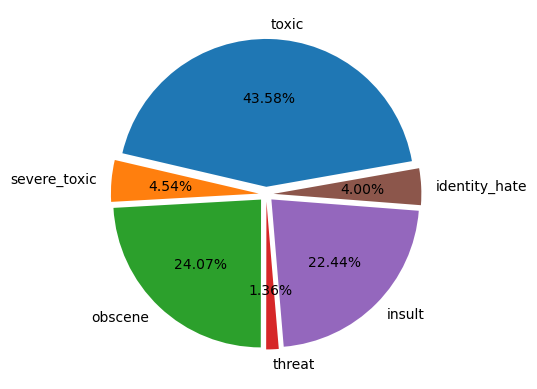

In [29]:
plt.pie(comments, autopct='%2.2f%%', labels = comments.index , startangle=10 , explode=(0.05,0.05,0.05,0.05,0.05,0.05))

In [30]:
total = df.sum(numeric_only  = True , axis = 1)
total 

0         0
1         0
2         0
3         0
4         0
         ..
159566    0
159567    0
159568    0
159569    0
159570    0
Length: 159571, dtype: int64

In [35]:
sum(total == 0) 

143346

In [36]:
newdf = pd.DataFrame({
    'neutral' : [sum(total == 0)],
    'toxic' : [sum(total != 0)]
})

In [38]:
newdf.T

,0
neutral,143346
toxic,16225


In [48]:
#### Data Cleaning 

In [56]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9]+' , ' ', text)
    return text

In [57]:
sample_text = "Hello, how are you?"
clean_text(sample_text)

'hello how are you '

In [61]:
# define input variables
comments = df['comment_text']

# define output variable 
labels = df.drop(['id' , 'comment_text'] ,axis =1)
labels

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
159566,0,0,0,0,0,0
159567,0,0,0,0,0,0
159568,0,0,0,0,0,0
159569,0,0,0,0,0,0


In [76]:
#### Clean Data
comments_text  = comments.apply(clean_text)
comments_text

0         explanation why the edits made under my userna...
1         d aww he matches this background colour i m se...
2         hey man i m really not trying to edit war it s...
3          more i can t make any real suggestions on imp...
4         you sir are my hero any chance you remember wh...
                                ...                        
159566     and for the second time of asking when your v...
159567    you should be ashamed of yourself that is a ho...
159568    spitzer umm theres no actual article for prost...
159569    and it looks like it was actually you who put ...
159570     and i really don t think you understand i cam...
Name: comment_text, Length: 159571, dtype: object

#### Prepare the input data

In [66]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential 
from keras.layers import Dense , Embedding , LSTM , GRU
from sklearn.model_selection import train_test_split

In [67]:
tokenizer = Tokenizer(num_words = 5000)
tokenizer.fit_on_texts(comments_text)
sequences = tokenizer.texts_to_sequences(comments_text)
padded = pad_sequences(sequences, maxlen=200, padding='post')

In [68]:
padded.shape

(159571, 200)

In [69]:
padded

array([[ 678,   77,    1, ...,    0,    0,    0],
       [ 161,   51, 2619, ...,    0,    0,    0],
       [ 407,  417,    3, ...,    0,    0,    0],
       ...,
       [  48,  732,   25, ...,    0,    0,    0],
       [   5,   10,  568, ...,    0,    0,    0],
       [   5,    3,  137, ...,    0,    0,    0]])

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    padded, 
    labels, 
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=0,    # Ensures you get the same split every time you run it
)

In [73]:
X_train.shape , y_train.shape

((127656, 200), (127656, 6))

In [74]:
X_test.shape , y_test.shape

((31915, 200), (31915, 6))

#### Build the model

In [77]:
model = Sequential()
model.add(Embedding(5000 , 100 , input_length = 200))
model.add(GRU(128))
model.add(Dense(6,activation = 'sigmoid'))

C:\Users\PGCP-AI\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [78]:
model.compile(
    loss='binary_crossentropy',  # Standard for binary classification
    optimizer='adam',            # Adaptive learning rate optimizer
    metrics=['accuracy']         # Track accuracy during training
)

#### Train the model

In [82]:
model.fit(X_train, y_train , epochs = 3 , validation_data=(X_test , y_test),verbose = 1)

Epoch 1/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 675s 168ms/step - accuracy: 0.9849 - loss: 0.0661 - val_accuracy: 0.9936 - val_loss: 0.0511
Epoch 2/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 658s 165ms/step - accuracy: 0.9837 - loss: 0.0469 - val_accuracy: 0.9886 - val_loss: 0.0487
Epoch 3/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 673s 169ms/step - accuracy: 0.9745 - loss: 0.0420 - val_accuracy: 0.9891 - val_loss: 0.0486


In [84]:
sample1 = 'You are stupid. No one cares about your opinion. Just shut up.'
sample2 = 'You are waste of time. World is better without you.'
sample3 = 'Your life will be so beautiful with her.'

In [85]:
def predict(new_comment):
    cleaned = clean_text(new_comment)
    new_seq = tokenizer.texts_to_sequences([cleaned])
    new_pad = pad_sequences(new_seq, maxlen=150)
    prediction = model.predict(new_pad, verbose=False)
    for i in range(len(prediction[0])):
        if prediction[0][i] > 0.5:
            print(toxicities[i])
    return prediction

In [86]:
toxicities = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [87]:
predict(sample1)

array([[0.3993349 , 0.02241413, 0.14409605, 0.01010263, 0.1147453 ,
        0.02258253]], dtype=float32)

In [88]:
predict(sample2)

array([[0.12563188, 0.00844609, 0.04990368, 0.00377227, 0.03987382,
        0.0075644 ]], dtype=float32)

In [89]:
predict(sample3)

array([[0.1275578 , 0.00415294, 0.04158724, 0.00309385, 0.03119273,
        0.00695941]], dtype=float32)